### Dataset: Energy Efficiency with HL (heating load) as target

In [2]:
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242) 
  
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets

var_df = energy_efficiency.variables
col_map = dict(zip(var_df["name"], var_df["description"]))
X = X.rename(columns=col_map)
y = y.rename(columns=col_map)

y = y[["Heating Load"]]
df = X.join(y)
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Train test split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,     
    random_state=42,   
    shuffle=True
)

print(f"#X_train = {len(X_train)}   #y_train = {len(y_train)}")
print(f"#X_test = {len(X_test)}     #y_test = {len(y_test)}")

#X_train = 691   #y_train = 691
#X_test = 77     #y_test = 77


### EDF normalization

In [4]:
from src.edf import edf_normalize, col_denorm

X_train_norm, X_test_norm, _ = edf_normalize(X_train, X_test)
y_train_norm, y_test_norm, edf_models = edf_normalize(y_train, y_test)

y_denorm = col_denorm("Heating Load", edf_models)

 ### Novelty (feature deg. 4, target deg. 4)

In [ ]:
from src.evaluation import novelty, report_novelty

columns_novelty = {}
for col in X.columns:
    print(f"--- Evaluating novelty for feature: {col} ---")
    softplus_novelty = novelty(X_train_norm, X_test_norm,
                                   y_train_norm, y_test_norm,
                                   col, y_test, y_denorm,   
                                   N_feature=4, N_target=4)

    param_softplus_novelty = novelty(X_train_norm, X_test_norm,
                                         y_train_norm, y_test_norm,
                                         col, y_test, y_denorm,
                                         N_feature=4, N_target=4,
                                         method="softplus", a=3., b=100.)

    clip_novelty = novelty(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,  
                               N_feature=4, N_target=4,
                               method="clip")

    columns_novelty[col] = {
        "softplus": softplus_novelty,
        "param-softplus": param_softplus_novelty,
        "clip": clip_novelty
    }

In [6]:
report_novelty(columns_novelty, method="softplus")

Feature Novelty Ranking (method: softplus):
1. Roof Area: 0.0633
2. Wall Area: 0.0371
3. Glazing Area: 0.0244
4. Relative Compactness: 0.0107
5. Surface Area: 0.0038
6. Overall Height: 0.0002
7. Orientation: -0.0013
8. Glazing Area Distribution: -0.0040


In [7]:
report_novelty(columns_novelty, method="param-softplus")

Feature Novelty Ranking (method: param-softplus):
1. Roof Area: 0.1167
2. Wall Area: 0.0479
3. Glazing Area: 0.0254
4. Relative Compactness: 0.0150
5. Surface Area: 0.0037
6. Overall Height: 0.0002
7. Orientation: -0.0038
8. Glazing Area Distribution: -0.0095


In [8]:
report_novelty(columns_novelty, method="clip")

Feature Novelty Ranking (method: clip):
1. Roof Area: 0.0827
2. Wall Area: 0.0578
3. Relative Compactness: 0.0127
4. Surface Area: 0.0047
5. Overall Height: 0.0001
6. Glazing Area: -0.0000
7. Orientation: -0.0016
8. Glazing Area Distribution: -0.0062


In [9]:
import pandas as pd

df_novelty = pd.DataFrame.from_dict(
    columns_novelty,
    orient="index"
)
df_novelty

,softplus,param-softplus,clip
Relative Compactness,0.010675,0.014992,0.012722
Surface Area,0.003797,0.003719,0.004663
Wall Area,0.037055,0.047915,0.057830
Roof Area,0.063277,0.116739,0.082728
Overall Height,0.000219,0.000162,0.000099
Orientation,-0.001340,-0.003833,-0.001646
Glazing Area,0.024359,0.025362,-0.000019
Glazing Area Distribution,-0.003951,-0.009513,-0.006243


 ### CV for novelty (feature deg. 4, target deg. 4)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
softplus_results = cv_novelty(X, y,
                              N_feature=4, N_target=4)

CV Novelty Results (method: softplus):

Feature: Relative Compactness
  per fold: [0.01 0.01 0.   0.   0.   0.   0.01 0.   0.   0.  ]
  mean novelty : 0.0045
  std novelty  : 0.0021

Feature: Surface Area
  per fold: [ 0.  0.  0.  0.  0.  0.  0.  0. -0.  0.]
  mean novelty : 0.0012
  std novelty  : 0.0012

Feature: Wall Area
  per fold: [0.05 0.02 0.04 0.02 0.01 0.04 0.03 0.03 0.03 0.05]
  mean novelty : 0.0324
  std novelty  : 0.0131

Feature: Roof Area
  per fold: [0.06 0.04 0.05 0.05 0.03 0.05 0.06 0.01 0.03 0.04]
  mean novelty : 0.0424
  std novelty  : 0.0136

Feature: Overall Height
  per fold: [ 0. -0.  0.  0.  0. -0.  0.  0.  0.  0.]
  mean novelty : 0.0005
  std novelty  : 0.0006

Feature: Orientation
  per fold: [-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
  mean novelty : -0.0017
  std novelty  : 0.0010

Feature: Glazing Area
  per fold: [0.04 0.04 0.05 0.03 0.05 0.04 0.04 0.02 0.04 0.03]
  mean novelty : 0.0390
  std novelty  : 0.0093

Feature: Glazing Area Distribution
  per 

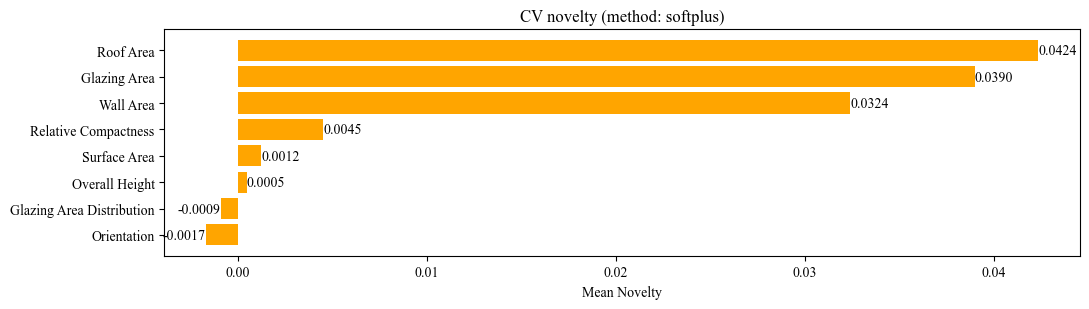

In [11]:
print_cv_novelty(softplus_results, X.columns)
plot_cv_novelty(softplus_results, X.columns)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
param_softplus_results = cv_novelty(X, y,
                                    N_feature=4, N_target=4,
                                    method="softplus", a=3., b=100.)

CV Novelty Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [0.02 0.   0.01 0.   0.   0.01 0.01 0.   0.   0.  ]
  mean novelty : 0.0050
  std novelty  : 0.0036

Feature: Surface Area
  per fold: [ 0.01  0.   -0.   -0.   -0.    0.    0.   -0.   -0.    0.  ]
  mean novelty : 0.0008
  std novelty  : 0.0026

Feature: Wall Area
  per fold: [ 0.09  0.01  0.04 -0.    0.    0.06  0.03  0.02  0.02  0.07]
  mean novelty : 0.0345
  std novelty  : 0.0301

Feature: Roof Area
  per fold: [0.12 0.06 0.08 0.09 0.04 0.11 0.12 0.01 0.05 0.08]
  mean novelty : 0.0750
  std novelty  : 0.0352

Feature: Overall Height
  per fold: [ 0. -0.  0.  0.  0. -0.  0.  0.  0.  0.]
  mean novelty : 0.0012
  std novelty  : 0.0011

Feature: Orientation
  per fold: [-0.01 -0.01 -0.   -0.01 -0.   -0.   -0.01  0.   -0.   -0.  ]
  mean novelty : -0.0037
  std novelty  : 0.0030

Feature: Glazing Area
  per fold: [0.05 0.09 0.11 0.05 0.08 0.08 0.1  0.06 0.07 0.09]
  mean novelty : 0.0782
  std nove

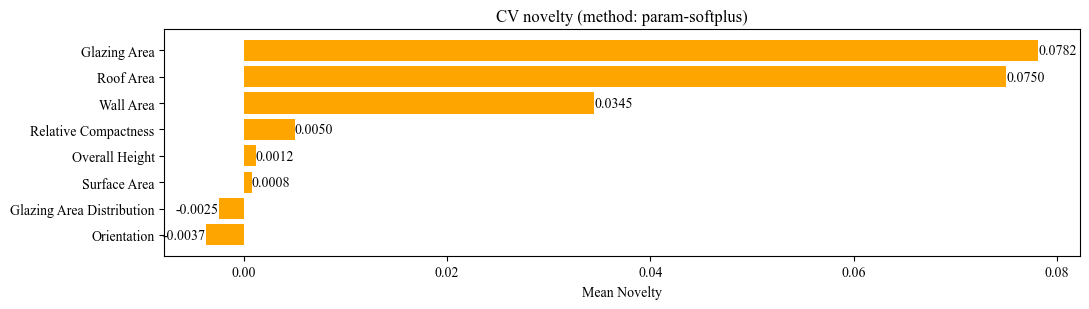

In [13]:
print_cv_novelty(param_softplus_results, X.columns, method="param-softplus")
plot_cv_novelty(param_softplus_results, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
clip_results = cv_novelty(X, y,
                          N_feature=4, N_target=4,
                          method="clip")

CV Novelty Results (method: clip):

Feature: Relative Compactness
  per fold: [ 0.01 -0.    0.01 -0.    0.01  0.    0.01  0.    0.    0.  ]
  mean novelty : 0.0038
  std novelty  : 0.0039

Feature: Surface Area
  per fold: [ 0.  0.  0.  0. -0.  0.  0.  0.  0.  0.]
  mean novelty : 0.0017
  std novelty  : 0.0014

Feature: Wall Area
  per fold: [ 0.07  0.02  0.06  0.01  0.03  0.06  0.04  0.04  0.04 -0.07]
  mean novelty : 0.0288
  std novelty  : 0.0386

Feature: Roof Area
  per fold: [0.07 0.04 0.07 0.04 0.04 0.07 0.07 0.02 0.04 0.06]
  mean novelty : 0.0523
  std novelty  : 0.0190

Feature: Overall Height
  per fold: [ 0. -0.  0. -0.  0. -0.  0.  0.  0.  0.]
  mean novelty : 0.0001
  std novelty  : 0.0012

Feature: Orientation
  per fold: [-0.   -0.01 -0.   -0.01 -0.   -0.   -0.   -0.   -0.   -0.  ]
  mean novelty : -0.0026
  std novelty  : 0.0022

Feature: Glazing Area
  per fold: [ 0.01  0.01  0.03  0.01  0.03  0.03  0.03 -0.01  0.01  0.01]
  mean novelty : 0.0148
  std novelty  : 0.0

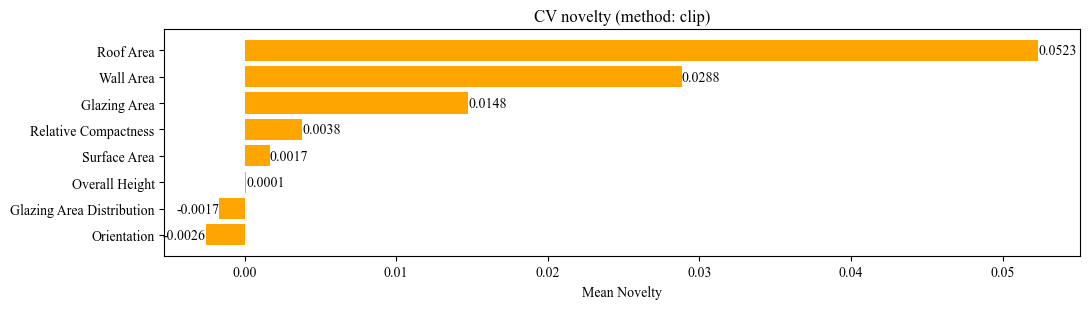

In [15]:
print_cv_novelty(clip_results, X.columns, method="clip")
plot_cv_novelty(clip_results, X.columns, method="clip")

In [16]:
from src.evaluation import novelty_to_df
novelty_df = novelty_to_df(softplus_results,
                           param_softplus_results,
                           clip_results)
novelty_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.004539  0.002079       0.005014  0.003636   
Surface Area               0.001239  0.001225       0.000804  0.002616   
Wall Area                  0.032405  0.013141       0.034492  0.030142   
Roof Area                  0.042362  0.013608       0.075005  0.035152   
Overall Height             0.000472  0.000574       0.001181  0.001108   
Orientation               -0.001681  0.000983      -0.003726  0.002988   
Glazing Area               0.038996  0.009261       0.078180  0.018333   
Glazing Area Distribution -0.000887  0.002268      -0.002470  0.006051   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.003790  0.003939  
Surface Area               0.001669  0.001433  
Wall Area                  0.028832  0.038573  
Roof Area                  0.052348  0.019019  
Overall Height             0.000115  0.001158  
Orientation               -0.002553  0.002173  
Glazing Area               0.014766  0.011532  
Glazing Area Distribution -0.001678  0.002755

 ### Novelty (feature deg. 7, target deg. 7)

In [ ]:
from src.evaluation import novelty, report_novelty

columns_novelty_higher_degs = {}
for col in X.columns:
    print(f"--- Evaluating novelty for feature: {col} ---")
    softplus_novelty = novelty(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,   
                               N_feature=7, N_target=7)

    param_softplus_novelty = novelty(X_train_norm, X_test_norm,
                                     y_train_norm, y_test_norm,
                                     col, y_test, y_denorm,
                                     N_feature=7, N_target=7,
                                     method="softplus", a=3., b=100.)

    clip_novelty = novelty(X_train_norm, X_test_norm,
                           y_train_norm, y_test_norm,
                           col, y_test, y_denorm,  
                           N_feature=7, N_target=7,
                           method="clip")

    columns_novelty_higher_degs[col] = {
        "softplus": softplus_novelty,
        "param-softplus": param_softplus_novelty,
        "clip": clip_novelty
    }

In [18]:
report_novelty(columns_novelty_higher_degs, method="softplus")

Feature Novelty Ranking (method: softplus):
1. Glazing Area: 0.0844
2. Wall Area: 0.0057
3. Relative Compactness: 0.0025
4. Surface Area: 0.0021
5. Roof Area: 0.0006
6. Overall Height: 0.0001
7. Orientation: -0.0036
8. Glazing Area Distribution: -0.0075


In [19]:
report_novelty(columns_novelty_higher_degs, method="param-softplus")

Feature Novelty Ranking (method: param-softplus):
1. Glazing Area: 0.2072
2. Surface Area: 0.0025
3. Relative Compactness: 0.0018
4. Roof Area: 0.0004
5. Overall Height: 0.0002
6. Wall Area: -0.0014
7. Orientation: -0.0067
8. Glazing Area Distribution: -0.0171


In [20]:
report_novelty(columns_novelty_higher_degs, method="clip")

Feature Novelty Ranking (method: clip):
1. Glazing Area: 0.0322
2. Wall Area: 0.0040
3. Relative Compactness: 0.0030
4. Surface Area: 0.0024
5. Roof Area: 0.0007
6. Overall Height: 0.0001
7. Orientation: -0.0046
8. Glazing Area Distribution: -0.0083


In [21]:
import pandas as pd

df_novelty = pd.DataFrame.from_dict(
    columns_novelty_higher_degs,
    orient="index"
)
df_novelty

,softplus,param-softplus,clip
Relative Compactness,0.002456,0.001850,0.003001
Surface Area,0.002098,0.002522,0.002446
Wall Area,0.005703,-0.001401,0.003969
Roof Area,0.000566,0.000432,0.000660
Overall Height,0.000112,0.000241,0.000106
Orientation,-0.003624,-0.006659,-0.004578
Glazing Area,0.084435,0.207184,0.032192
Glazing Area Distribution,-0.007461,-0.017088,-0.008288


 ### CV for novelty (feature deg. 7, target deg. 7)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
softplus_results_higher_degs = cv_novelty(X, y,
                                          N_feature=7, N_target=7)

CV Novelty Results (method: softplus):

Feature: Relative Compactness
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0011
  std novelty  : 0.0003

Feature: Surface Area
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0009
  std novelty  : 0.0003

Feature: Wall Area
  per fold: [ 0.01  0.01  0.01  0.    0.    0.   -0.    0.   -0.    0.  ]
  mean novelty : 0.0034
  std novelty  : 0.0043

Feature: Roof Area
  per fold: [-0.  0.  0. -0.  0.  0. -0.  0.  0.  0.]
  mean novelty : 0.0001
  std novelty  : 0.0002

Feature: Overall Height
  per fold: [ 0.  0.  0.  0.  0. -0.  0.  0. -0.  0.]
  mean novelty : 0.0002
  std novelty  : 0.0002

Feature: Orientation
  per fold: [-0.   -0.01 -0.   -0.   -0.   -0.01 -0.   -0.   -0.   -0.  ]
  mean novelty : -0.0034
  std novelty  : 0.0015

Feature: Glazing Area
  per fold: [0.08 0.12 0.13 0.05 0.11 0.11 0.11 0.09 0.1  0.1 ]
  mean novelty : 0.0986
  std novelty  : 0.0225

Feature: Glazing Area Distribution
  per fold: [-0.

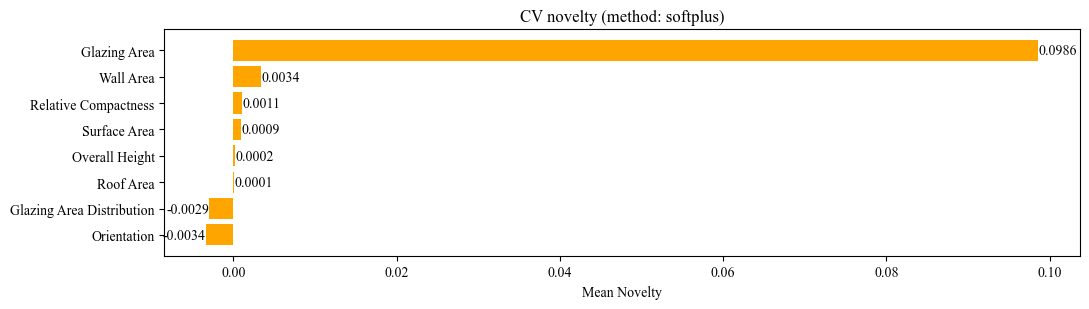

In [23]:
print_cv_novelty(softplus_results_higher_degs, X.columns)
plot_cv_novelty(softplus_results_higher_degs, X.columns)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
param_softplus_results_higher_degs = cv_novelty(X, y,
                                                N_feature=7, N_target=7,
                                                method="softplus", a=3., b=100.)

CV Novelty Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [-0. -0.  0. -0. -0. -0.  0. -0.  0.  0.]
  mean novelty : -0.0007
  std novelty  : 0.0013

Feature: Surface Area
  per fold: [ 0.  0. -0. -0. -0. -0.  0.  0.  0.  0.]
  mean novelty : 0.0006
  std novelty  : 0.0013

Feature: Wall Area
  per fold: [ 0.02  0.    0.   -0.   -0.   -0.01 -0.01 -0.   -0.01  0.  ]
  mean novelty : -0.0004
  std novelty  : 0.0100

Feature: Roof Area
  per fold: [ 0.  0. -0. -0.  0.  0.  0.  0.  0.  0.]
  mean novelty : 0.0001
  std novelty  : 0.0005

Feature: Overall Height
  per fold: [-0.  0. -0.  0.  0. -0. -0.  0. -0.  0.]
  mean novelty : 0.0002
  std novelty  : 0.0005

Feature: Orientation
  per fold: [-0.01 -0.01 -0.   -0.01 -0.   -0.01 -0.01 -0.01 -0.01 -0.01]
  mean novelty : -0.0076
  std novelty  : 0.0036

Feature: Glazing Area
  per fold: [0.12 0.26 0.28 0.09 0.23 0.22 0.25 0.25 0.22 0.24]
  mean novelty : 0.2164
  std novelty  : 0.0575

Feature: Glazing Area D

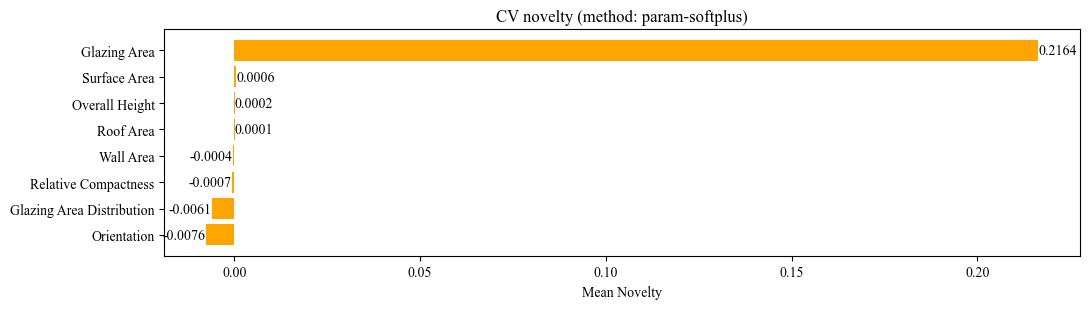

In [25]:
print_cv_novelty(param_softplus_results_higher_degs, X.columns, method="param-softplus")
plot_cv_novelty(param_softplus_results_higher_degs, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
clip_results_higher_degs = cv_novelty(X, y,
                                      N_feature=7, N_target=7,
                                      method="clip")

CV Novelty Results (method: clip):

Feature: Relative Compactness
  per fold: [ 0.   -0.01  0.    0.    0.    0.    0.    0.    0.    0.  ]
  mean novelty : 0.0001
  std novelty  : 0.0026

Feature: Surface Area
  per fold: [ 0. -0.  0. -0.  0.  0.  0.  0.  0.  0.]
  mean novelty : 0.0006
  std novelty  : 0.0009

Feature: Wall Area
  per fold: [ 0.01 -0.    0.01  0.    0.    0.01 -0.01  0.   -0.    0.01]
  mean novelty : 0.0027
  std novelty  : 0.0055

Feature: Roof Area
  per fold: [ 0.  0.  0. -0.  0.  0.  0.  0.  0.  0.]
  mean novelty : 0.0007
  std novelty  : 0.0012

Feature: Overall Height
  per fold: [-0.  0.  0.  0.  0. -0. -0.  0. -0.  0.]
  mean novelty : 0.0004
  std novelty  : 0.0009

Feature: Orientation
  per fold: [-0.   -0.   -0.   -0.01 -0.   -0.01 -0.   -0.   -0.   -0.  ]
  mean novelty : -0.0042
  std novelty  : 0.0018

Feature: Glazing Area
  per fold: [ 0.01  0.07  0.07 -0.03  0.05  0.06  0.06  0.03  0.05  0.05]
  mean novelty : 0.0422
  std novelty  : 0.0285

Featu

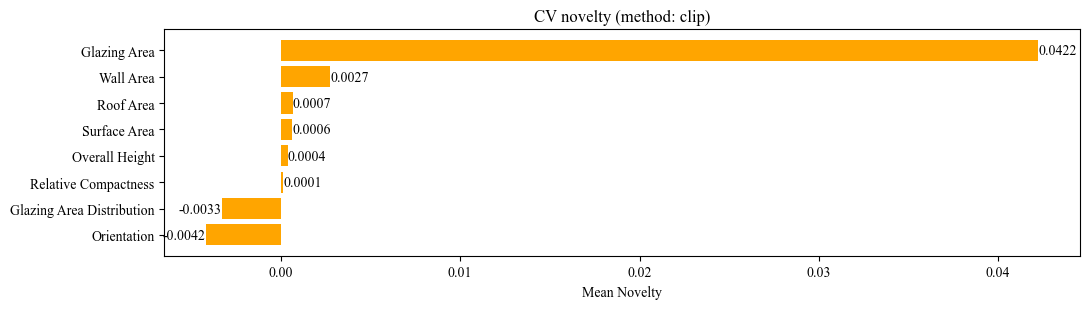

In [27]:
print_cv_novelty(clip_results_higher_degs, X.columns, method="clip")
plot_cv_novelty(clip_results_higher_degs, X.columns, method="clip")

In [28]:
from src.evaluation import novelty_to_df
novelty_df = novelty_to_df(softplus_results_higher_degs,
                           param_softplus_results_higher_degs,
                           clip_results_higher_degs)
novelty_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.001089  0.000347      -0.000718  0.001272   
Surface Area               0.000939  0.000280       0.000579  0.001320   
Wall Area                  0.003420  0.004308      -0.000431  0.009964   
Roof Area                  0.000132  0.000209       0.000087  0.000513   
Overall Height             0.000208  0.000163       0.000153  0.000500   
Orientation               -0.003373  0.001500      -0.007644  0.003580   
Glazing Area               0.098608  0.022510       0.216402  0.057478   
Glazing Area Distribution -0.002933  0.003953      -0.006069  0.008944   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.000145  0.002617  
Surface Area               0.000646  0.000876  
Wall Area                  0.002744  0.005463  
Roof Area                  0.000654  0.001168  
Overall Height             0.000388  0.000895  
Orientation               -0.004184  0.001819  
Glazing Area               0.042240  0.028500  
Glazing Area Distribution -0.003307  0.004157